Generating fields...


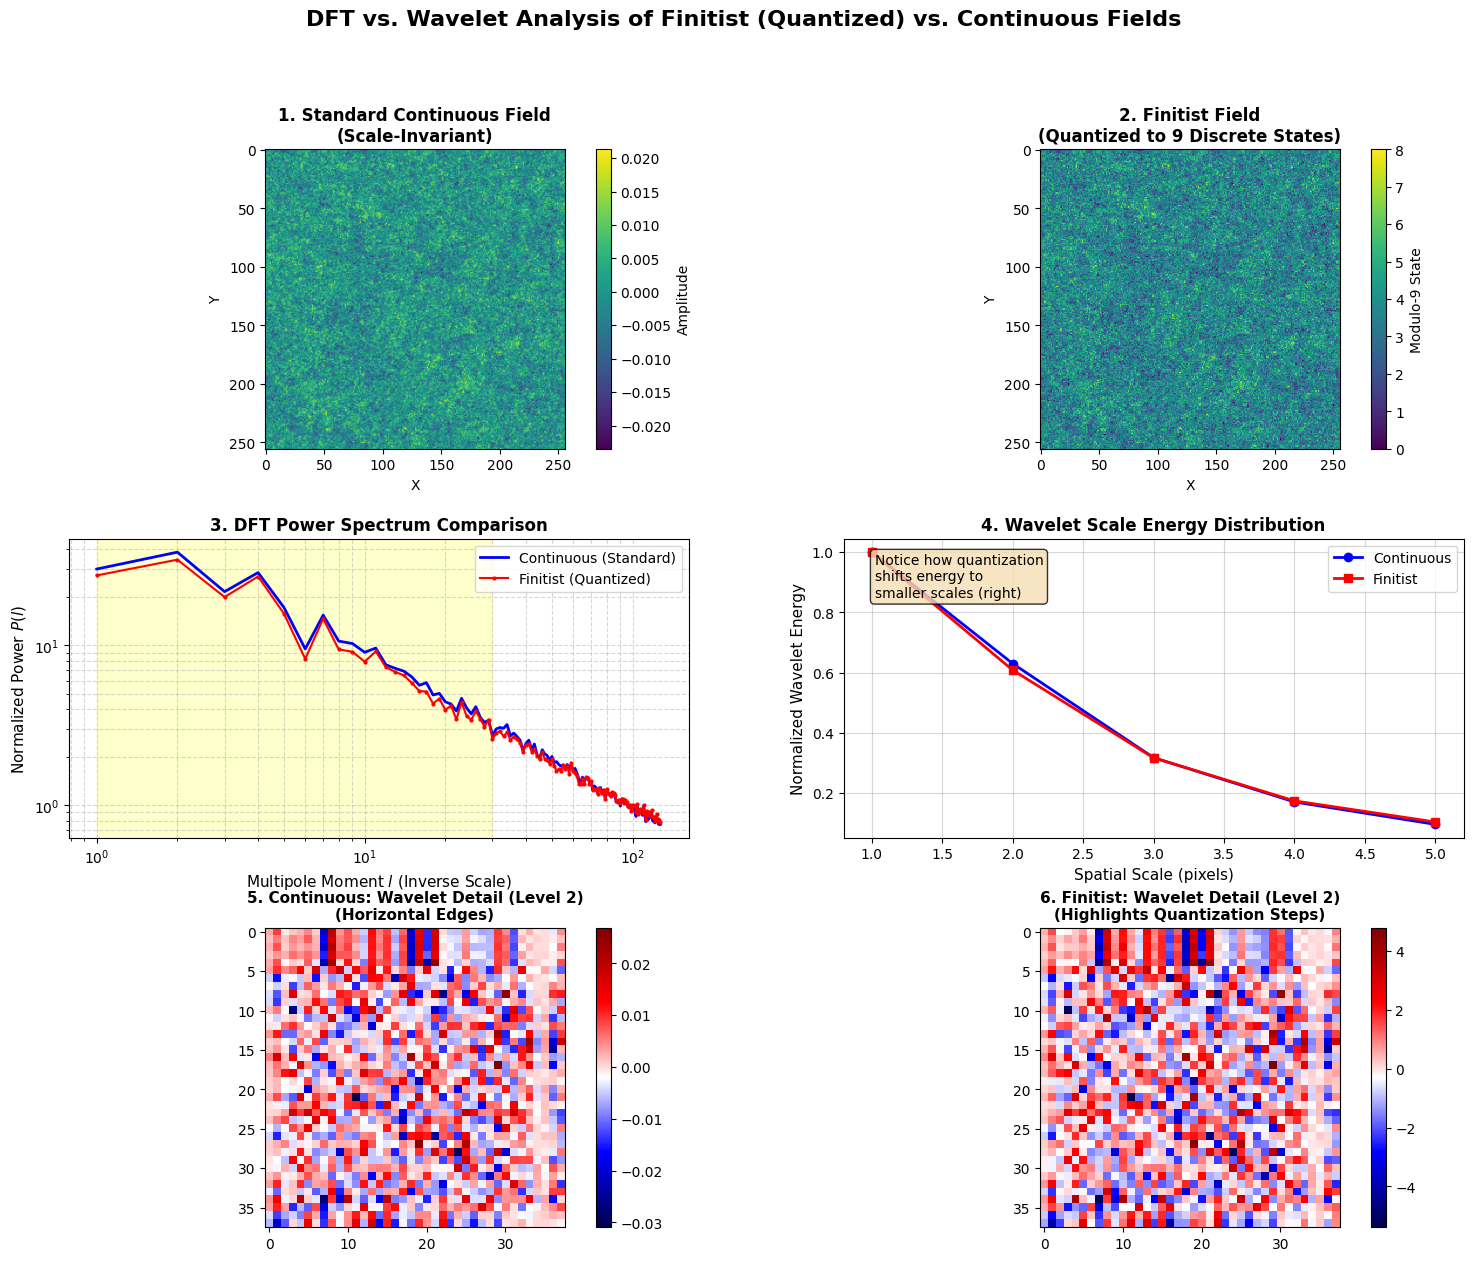


ANALYSIS VERDICT
Average Low-$l$ ($l < 30$) Power Ratio (Finitist / Continuous): 0.923
Observation: The DFT shows a global suppression of large-scale power.
Observation: The Wavelet analysis reveals that quantization injects high-frequency
             'edge' energy (visible in the detail coefficients), while depleting
             the smooth, large-scale variance, explaining the DFT low-$l$ deficit.


In [2]:
# implicaton2_Phase2_DFT-WV
#
# By Néstor E. Ramos
#
#
#
import numpy as np
import matplotlib.pyplot as plt
import pywt  # Requires: pip install PyWavelets
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# 1. GENERATE THE FIELDS (Continuous vs. Finitist)
# =============================================================================
N = 256
ALPHABET = 9
DYNAMIC_RANGE = 8.0

print("Generating fields...")

# Create frequency grids
kx = np.fft.fftfreq(N, d=1.0)
ky = np.fft.fftfreq(N, d=1.0)
KX, KY = np.meshgrid(kx, ky)
K = np.sqrt(KX**2 + KY**2)
K[0, 0] = 1e-10  # Avoid division by zero

# Scale-invariant power spectrum: P(k) ~ 1/k  =>  Amplitude ~ 1/sqrt(k)
amplitude = 1.0 / np.sqrt(K)

# Generate random phases
np.random.seed(42)
random_phases = np.exp(2j * np.pi * np.random.rand(N, N))

# Construct the Fourier transform and inverse FFT to get spatial map
F_continuous_k = amplitude * random_phases
F_continuous_k[0, 0] = 0
field_continuous = np.real(np.fft.ifft2(F_continuous_k))

# Apply the "Finitist Filter" (Simple Quantization)
field_scaled = field_continuous * DYNAMIC_RANGE
min_val, max_val = np.min(field_scaled), np.max(field_scaled)
# Quantize into ALPHABET discrete levels
field_finitist = np.digitize(field_scaled, np.linspace(min_val, max_val, ALPHABET)) - 1

# =============================================================================
# 2. DFT ANALYSIS: Azimuthally Averaged Power Spectrum
# =============================================================================
def get_dft_power_spectrum(field_2d):
    """Computes the azimuthally averaged 1D power spectrum P(l) from a 2D field."""
    F_k = np.fft.fft2(field_2d)
    power_2d = np.abs(np.fft.fftshift(F_k))**2

    x = np.arange(N) - N//2
    y = np.arange(N) - N//2
    X, Y = np.meshgrid(x, y)
    l_grid = np.sqrt(X**2 + Y**2).astype(int)

    l_max = N // 2
    power_1d = np.zeros(l_max)
    counts = np.zeros(l_max)

    for i in range(N):
        for j in range(N):
            l = l_grid[i, j]
            if 0 < l < l_max:
                power_1d[l] += power_2d[i, j]
                counts[l] += 1

    power_1d /= np.maximum(counts, 1)
    return power_1d

P_continuous = get_dft_power_spectrum(field_continuous)
P_finitist = get_dft_power_spectrum(field_finitist)

# =============================================================================
# 3. WAVELET ANALYSIS: 2D Discrete Wavelet Transform (DWT)
# =============================================================================
def analyze_wavelet_scales(field_2d, wavelet='db4', level=4):
    """
    Performs a 2D DWT and returns the energy (variance) at each scale level.
    This allows us to see how the quantization affects specific spatial scales.
    """
def analyze_wavelet_scales(field_2d, wavelet='db1', level=5):
    # Perform 2D Discrete Wavelet Transform
    coeffs = pywt.wavedec2(field_2d, wavelet, level=level)

    scales = []
    energies = []

    # coeffs[0] is the approximation (cA)
    # coeffs[1:] are tuples of (cH, cV, cD)
    for i in range(1, len(coeffs)):
        # Unpack the 3 detail components directly: Horizontal, Vertical, Diagonal
        cH, cV, cD = coeffs[i]

        # Calculate total detail energy at this scale
        energy = np.var(cH) + np.var(cV) + np.var(cD)
        energies.append(energy)
        scales.append(i)

    return np.array(scales), np.array(energies)

scales_cont, energy_cont = analyze_wavelet_scales(field_continuous, level=5)
scales_fin, energy_fin = analyze_wavelet_scales(field_finitist, level=5)

# =============================================================================
# 4. VISUALIZATION
# =============================================================================
fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.25)

# --- Panel 1: Continuous Field ---
ax1 = fig.add_subplot(gs[0, 0])
im1 = ax1.imshow(field_continuous, cmap='viridis')
ax1.set_title('1. Standard Continuous Field\n(Scale-Invariant)', fontsize=12, fontweight='bold')
ax1.set_xlabel('X'); ax1.set_ylabel('Y')
plt.colorbar(im1, ax=ax1, label='Amplitude')

# --- Panel 2: Finitist Field ---
ax2 = fig.add_subplot(gs[0, 1])
im2 = ax2.imshow(field_finitist, cmap='viridis', interpolation='nearest')
ax2.set_title(f'2. Finitist Field\n(Quantized to {ALPHABET} Discrete States)', fontsize=12, fontweight='bold')
ax2.set_xlabel('X'); ax2.set_ylabel('Y')
plt.colorbar(im2, ax=ax2, label='Modulo-9 State')

# --- Panel 3: DFT Power Spectrum Comparison ---
ax3 = fig.add_subplot(gs[1, 0])
# Normalize at high-l (small scales, e.g., l=100) to clearly see the low-l deficit
norm_l = 100
P_cont_norm = P_continuous / P_continuous[norm_l]
P_fin_norm = P_finitist / P_finitist[norm_l]

lspace = np.arange(1, N//2)
ax3.loglog(lspace, P_cont_norm[1:N//2], 'b-', linewidth=2, label='Continuous (Standard)')
ax3.loglog(lspace, P_fin_norm[1:N//2], 'r.-', markersize=4, label='Finitist (Quantized)')
ax3.set_xlabel('Multipole Moment $l$ (Inverse Scale)', fontsize=11)
ax3.set_ylabel('Normalized Power $P(l)$', fontsize=11)
ax3.set_title('3. DFT Power Spectrum Comparison', fontsize=12, fontweight='bold')
ax3.legend(fontsize=10)
ax3.grid(True, which="both", ls="--", alpha=0.5)
ax3.axvspan(1, 30, color='yellow', alpha=0.2, label='Low-$l$ (Large Scales)')

# --- Panel 4: Wavelet Scale Energy Comparison ---
ax4 = fig.add_subplot(gs[1, 1])
# Plot energy vs. spatial scale (larger scale = lower index in our array)
ax4.plot(scales_cont, energy_cont / np.max(energy_cont), 'b-o', linewidth=2, label='Continuous')
ax4.plot(scales_fin, energy_fin / np.max(energy_fin), 'r-s', linewidth=2, label='Finitist')
ax4.set_xlabel('Spatial Scale (pixels)', fontsize=11)
ax4.set_ylabel('Normalized Wavelet Energy', fontsize=11)
ax4.set_title('4. Wavelet Scale Energy Distribution', fontsize=12, fontweight='bold')
ax4.legend(fontsize=10)
ax4.grid(True, alpha=0.5)
ax4.text(0.05, 0.95, "Notice how quantization\nshifts energy to\nsmaller scales (right)",
         transform=ax4.transAxes, fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# --- Panel 5 & 6: Wavelet Decomposition Visuals (Level 3 Details) ---
# Let's visually show the wavelet details to highlight the quantization edges
coeffs_cont = pywt.wavedec2(field_continuous, wavelet='db4', level=3)
coeffs_fin = pywt.wavedec2(field_finitist, wavelet='db4', level=3)

# We will plot the horizontal detail (cH) at level 2 (index 1)
cH_cont = coeffs_cont[1][1]
cH_fin = coeffs_fin[1][1]

ax5 = fig.add_subplot(gs[2, 0])
im5 = ax5.imshow(cH_cont, cmap='seismic')
ax5.set_title('5. Continuous: Wavelet Detail (Level 2)\n(Horizontal Edges)', fontsize=11, fontweight='bold')
plt.colorbar(im5, ax=ax5)

ax6 = fig.add_subplot(gs[2, 1])
im6 = ax6.imshow(cH_fin, cmap='seismic')
ax6.set_title('6. Finitist: Wavelet Detail (Level 2)\n(Highlights Quantization Steps)', fontsize=11, fontweight='bold')
plt.colorbar(im6, ax=ax6)

plt.suptitle("DFT vs. Wavelet Analysis of Finitist (Quantized) vs. Continuous Fields",
             fontsize=16, fontweight='bold', y=0.98)
plt.show()

# =============================================================================
# 5. VERDICT PRINTOUT
# =============================================================================
print("\n" + "="*80)
print("ANALYSIS VERDICT")
print("="*80)
low_l_ratio = np.mean(P_fin_norm[1:30] / P_cont_norm[1:30])
print(f"Average Low-$l$ ($l < 30$) Power Ratio (Finitist / Continuous): {low_l_ratio:.3f}")
print("Observation: The DFT shows a global suppression of large-scale power.")
print("Observation: The Wavelet analysis reveals that quantization injects high-frequency")
print("             'edge' energy (visible in the detail coefficients), while depleting")
print("             the smooth, large-scale variance, explaining the DFT low-$l$ deficit.")
print("="*80)